# Análise de Dados com Python - TP3

https://deepnote.com/app/infnet-1d7e/Analise-com-Python-7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e?utm_source=app-settings&utm_medium=product-shared-content&utm_campaign=data-app&utm_content=7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")


df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Questão 1 - Gráficos básicos com Matplotlib

1.2 - Crie um gráfico de barras verticais comparando totais por categorias

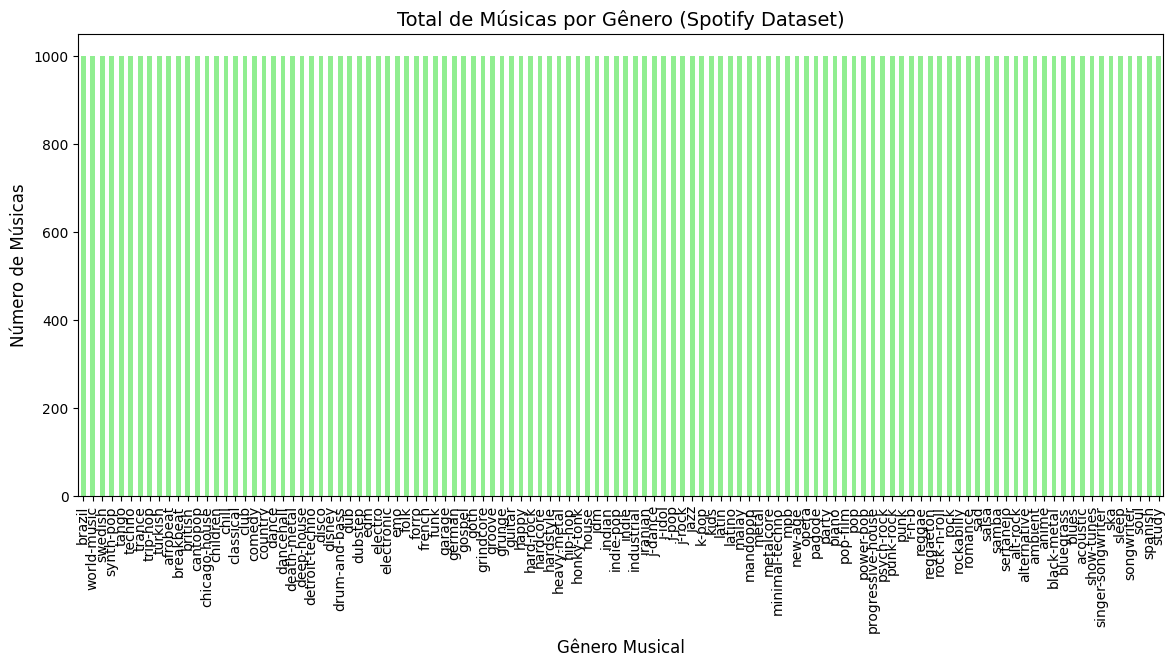

In [2]:
# Contagem total de músicas por gênero (categorias)
genre_counts = df["track_genre"].value_counts().sort_values(ascending=False)

# Criar gráfico de barras verticais
plt.figure(figsize=(14,6))
genre_counts.plot(kind="bar", color="lightgreen")
plt.title("Total de Músicas por Gênero (Spotify Dataset)", fontsize=14)
plt.xlabel("Gênero Musical", fontsize=12)
plt.ylabel("Número de Músicas", fontsize=12)
plt.xticks(rotation=90)
plt.show()

**Esse gráfico mostra o número total de faixas disponíveis em cada gênero dentro do dataset.**
**Insight principal: revela a representatividade dos gêneros na base de dados.**
**Importante para avaliar se há equilíbrio ou viés — alguns gêneros podem estar muito mais representados do que outros.**

<hr>

### Questão 2 - Estilo e subplots

2.1 Organize dois gráficos de linha em subplots horizontais para comparar diferentes métricas temporais.

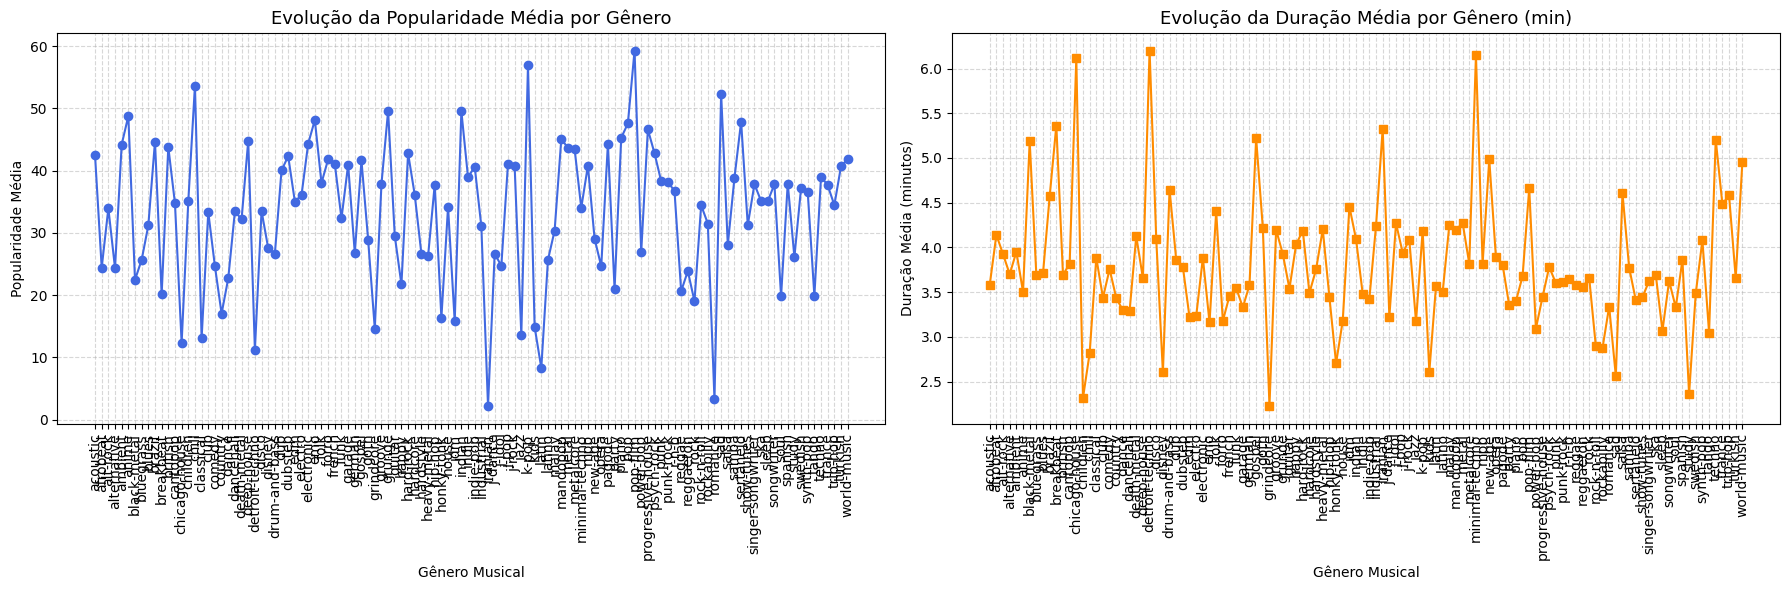

In [3]:
# Prepara métricas agregadas por gênero
genre_stats = df.groupby("track_genre").agg({
    "popularity": "mean",
    "duration_ms": "mean"
}).sort_index()

# Converte duração para minutos
genre_stats["duration_min"] = genre_stats["duration_ms"] / 60000

# Criar subplots horizontais
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharex=True)

# Gráfico 1 - Popularidade média por gênero
axes[0].plot(genre_stats.index, genre_stats["popularity"], marker="o", color="royalblue")
axes[0].set_title("Evolução da Popularidade Média por Gênero", fontsize=13)
axes[0].set_xlabel("Gênero Musical")
axes[0].set_ylabel("Popularidade Média")
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Gráfico 2 - Duração média por gênero
axes[1].plot(genre_stats.index, genre_stats["duration_min"], marker="s", color="darkorange")
axes[1].set_title("Evolução da Duração Média por Gênero (min)", fontsize=13)
axes[1].set_xlabel("Gênero Musical")
axes[1].set_ylabel("Duração Média (minutos)")
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**A escolha estética nos gráficos não é apenas uma questão de aparência, mas de clareza na transmissão da informação.** 
**O uso de cores contrastantes, subplots horizontais e marcadores nos pontos facilita a leitura e permite que compare diferentes métricas sem esforço.**

<hr>

### Questão 3 - Distribuições e padrões

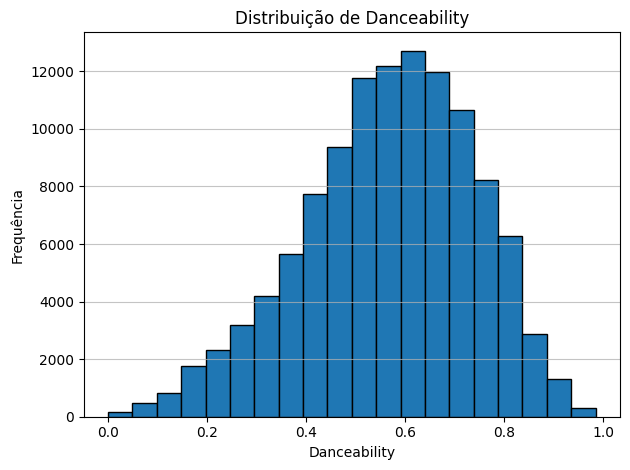

In [4]:
# Cria o histograma para a coluna 'danceability'
plt.hist(df['danceability'], bins=20, edgecolor='black')

plt.title('Distribuição de Danceability')
plt.xlabel('Danceability')
plt.ylabel('Frequência')

plt.grid(axis='y', alpha=0.75)

# Exibe o gráfico
plt.tight_layout()
plt.show()

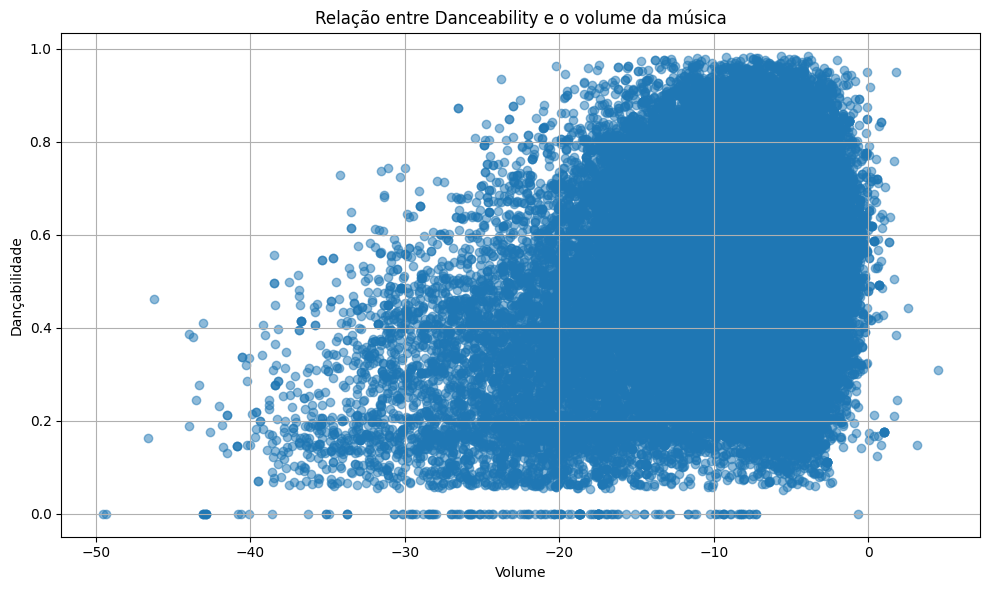

In [5]:
# Cria o gráfico de dispersão

df.dropna(inplace=True)

df['loudness'] = pd.to_numeric(df['loudness'], errors='coerce')
df['danceability'] = pd.to_numeric(df['danceability'], errors='coerce')
df.dropna(subset=['loudness', 'danceability'], inplace=True)

plt.figure(figsize=(10, 6))
plt.scatter(df['loudness'],df['danceability'], alpha=0.5)

# Adiciona um título e rótulos aos eixos
plt.title('Relação entre Danceability e o volume da música')
plt.xlabel('Volume')
plt.ylabel('Dançabilidade')

plt.grid(True)
# Exibe o gráfico
plt.tight_layout()
plt.show()

O gráfico indica que o volume da faixa não tem relação direta com a sua dançabilidade, sugerindo que outros fatores musicais são mais determinantes para o quanto uma música é “dançável”.

Há alguns pontos com volume abaixo de -40 dB (muito fora da faixa comum).

Esses podem representar erros de medição ou faixas com silêncio prolongado 

Também existem alguns pontos de dançabilidade exatamente 0, o que pode indicar músicas classificadas como não dançáveis ou até dados ausentes/erro de processamento.

<hr>

### Questão 4 - Proporções e dados angulares

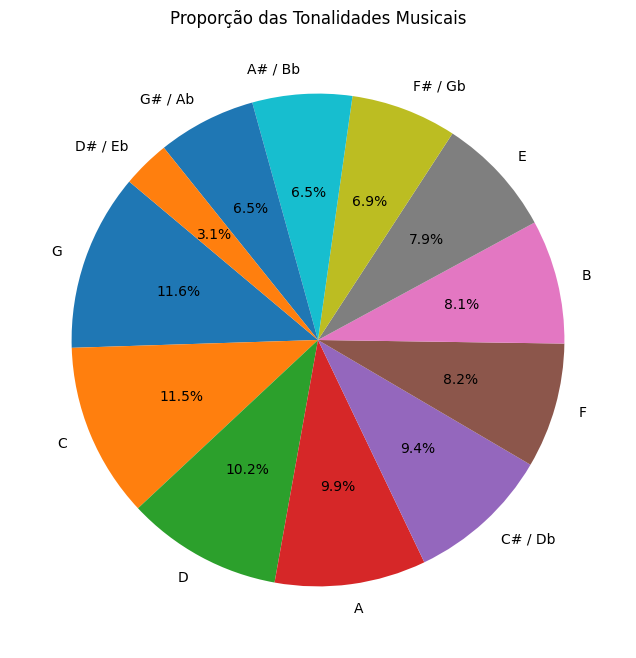

In [15]:

key_map = {
    0: "C",
    1: "C# / Db",
    2: "D",
    3: "D# / Eb",
    4: "E",
    5: "F",
    6: "F# / Gb",
    7: "G",
    8: "G# / Ab",
    9: "A",
    10: "A# / Bb",
    11: "B"
}

df["key_note"] = df["key"].map(key_map)
notes_counts = df['key_note'].value_counts()

# Criar gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(notes_counts, labels=notes_counts.index, autopct='%1.1f%%', startangle=140)

plt.title("Proporção das Tonalidades Musicais")
plt.show()

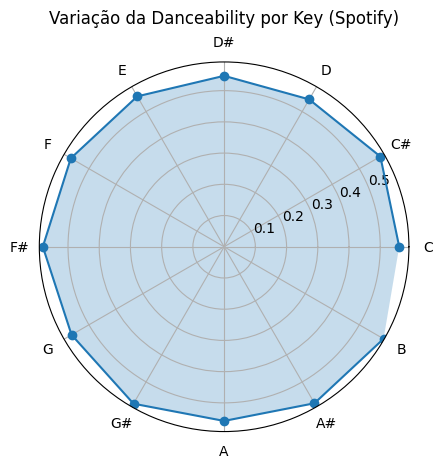

In [24]:
# Agrupa por 'key' e calcula a média da danceability
media_danceability = df.groupby('key')['danceability'].mean()

# Chaves e valores
keys = media_danceability.index
valores = media_danceability.values

# Converte keys para ângulos (radianos)
angulos = 2 * np.pi * keys / 12

# Cria gráfico polar
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(angulos, valores, marker='o')
ax.fill(angulos, valores, alpha=0.25)  # Preenchimento opcional

# Configurações estéticas
ax.set_xticks(angulos)
ax.set_xticklabels(['C', 'C#', 'D', 'D#', 'E', 'F', 
                    'F#', 'G', 'G#', 'A', 'A#', 'B'])
ax.set_title("Variação da Danceability por Key (Spotify)", va='bottom')

plt.show()

Gráficos polares e de pizza são bons para mostrar padrões cíclicos de forma visual e intuitiva, mas não substituem gráficos lineares ou de barras quando a precisão ou muitas categorias são importantes.

<hr>

### Questão 5 - Exploração com Pandas + Matplotlib

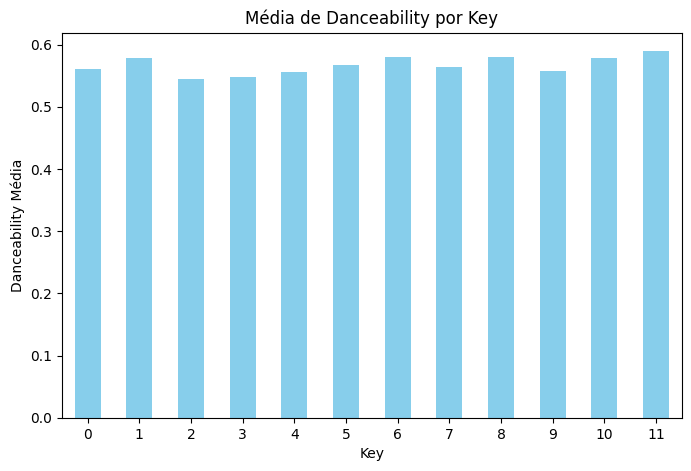

In [27]:
# Agregação: média da danceability por key
media_danceability = df.groupby('key')['danceability'].mean()

# Visualização simples usando pandas.plot()
media_danceability.plot(kind='bar', color='skyblue', figsize=(8,5), title='Média de Danceability por Key')
plt.xlabel('Key')
plt.ylabel('Danceability Média')
plt.xticks(rotation=0)  # Mantém labels horizontais
plt.show()

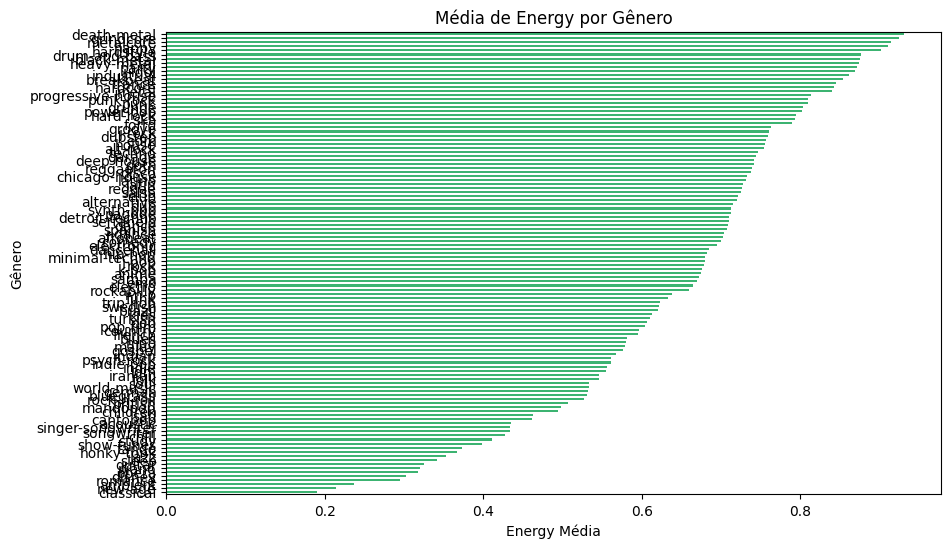

In [30]:
# Agregação: média de energy por gênero
media_energy_genero = df.groupby('track_genre')['energy'].mean().sort_values(ascending=True)

# Plotando gráfico de barras horizontais
media_energy_genero.plot(kind='barh', color='mediumseagreen', figsize=(10,6), title='Média de Energy por Gênero')
plt.xlabel('Energy Média')
plt.ylabel('Gênero')
plt.show()

O uso combinado de Pandas e Matplotlib facilita a análise exploratória de dados, pois Pandas permite manipular, agregar e organizar informações de forma rápida, enquanto Matplotlib transforma esses dados em gráficos claros e personalizáveis. Essa integração permite gerar visualizações de tendências, padrões de forma ágil, tornando o processo de exploração intuitivo e eficiente.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>